# 84 - Fine-tuning ResNet-18

**Section:** Transfer Learning | **Prereqs:** `Transfer Learning/TF_MNIST-_FMNIST.ipynb` | **Next:** `Transfer Learning/TF_VGG-16.ipynb`

Real transfer learning: take ResNet-18 pretrained on ImageNet (1.2M images, 1000
classes), replace its final layer, freeze everything else, and train on STL-10 -
5000 images. Minutes of training, accuracy that would take days from scratch.

**The recipe, four steps**
1. `models.resnet18(weights=DEFAULT)` - load the pretrained network.
2. `resnet.fc = nn.Linear(512, 10)` - replace the classifier. A newly created
   layer has `requires_grad=True` automatically.
3. Freeze everything except `fc`.
4. Optimize `filter(lambda p: p.requires_grad, model.parameters())` - passing all
   parameters would work, but this makes the intent explicit and skips the
   bookkeeping for frozen tensors.

**Normalize with ImageNet's statistics.** The `mean=[0.485,0.456,0.406]`,
`std=[0.229,0.224,0.225]` values are not decoration - the pretrained weights
expect inputs on that scale, and using anything else shifts every activation away
from what the network was trained on.

**What ResNet contributed:** residual connections, `y = f(x) + x`. The identity
path gives gradients a route back that does not pass through the weights, which is
what made 50- and 100-layer networks trainable. It is the direct answer to the
depth failure in `More on Data/DepthVsBreadth.ipynb`.

**Feature extraction vs fine-tuning:** this notebook does the first (backbone
frozen). The second, unfreezing the last block or two at a very small learning
rate, usually adds a few points when the target domain differs from ImageNet.

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader,TensorDataset, Subset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

import torchvision.models as models
import torchvision.datasets as datasets
import torchvision.transforms as T
import torchsummary

In [39]:
# STL-10: 96x96 colour, 10 classes, only 500 training images per class -
# deliberately small, which is exactly the situation transfer learning is for.
# The Normalize values are ImageNet's channel means and standard deviations. Use
# these EXACT numbers with any ImageNet-pretrained model: it was trained on
# inputs normalised this way, and different statistics shift every activation
# away from what its weights expect.
transformations = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # These numbers are recommended in the ResNet Paper
])

trainset = datasets.STL10(root='/',split='train', download=True, transform=transformations)
testset = datasets.STL10(root='/',split='test', download=True, transform=transformations)

In [40]:
device = ('cuda' if torch.cuda.is_available() else 'cpu')
device

'cuda'

In [41]:
trainset

Dataset STL10
    Number of datapoints: 5000
    Root location: /
    Split: train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )

In [42]:
# Batch 32 for training; 256 for evaluation, where no gradients are stored.
bs = 32
train_loader = DataLoader(trainset, batch_size=bs, drop_last=True,shuffle=True)
test_loader = DataLoader(testset, batch_size=256)

In [43]:
# Shapes and class names. 5000 training images across 10 classes - too few to
# train a deep CNN from scratch, which is the premise.
print("Train data shape")
print(trainset.data.shape, trainset.labels.shape)


print("\nTest data shape")
print(testset.data.shape, testset.labels.shape)

print("\nCategories")
print(testset.classes)

Train data shape
(5000, 3, 96, 96) (5000,)

Test data shape
(8000, 3, 96, 96) (8000,)

Categories
['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [44]:
# Min and max after normalisation: roughly -2 to +2, not 0 to 1. That is what
# Normalize with ImageNet statistics does.
X,y = next(iter(train_loader))

print(X.shape, y.shape)

print("\nMin and Max vals:")
print(torch.min(X), torch.max(X))

torch.Size([32, 3, 96, 96]) torch.Size([32])

Min and Max vals:
tensor(-2.1179) tensor(2.6400)


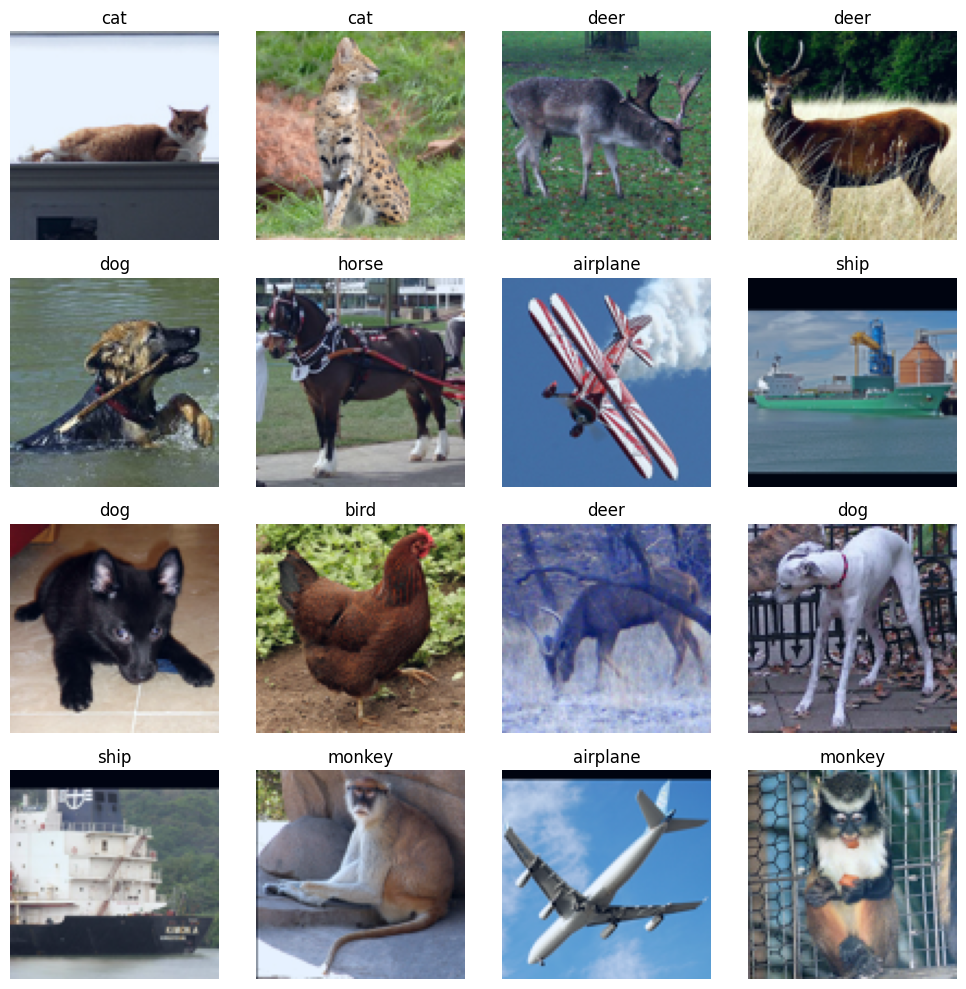

In [45]:
# Sample images, un-normalised for display. Note the transpose back to (H,W,C)
# and the rescale to [0,1] - normalised tensors cannot be plotted directly.
fig, axs = plt.subplots(4,4,figsize=(10,10))
for (i, ax) in enumerate(axs.flatten()) :
    if i >= len(X):
        break

    # extract that image (need to transpose it back to HxWxC from CxHxW)
    pic = X[i].numpy().transpose((1,2,0))

    # undo normalization (rescale to 0-1 for display)
    pic = pic - np.min(pic)
    # Avoid division by zero if all pixels are the same value (e.g., all zeros)
    if np.max(pic) > 0:
        pic = pic / np.max(pic)

    # and its label (convert tensor to Python scalar for indexing)
    label = trainset.classes[y[i].item()]
    ax.imshow(pic)
    ax.set_title(label)
    ax.axis('off')

plt.tight_layout()
plt.show()

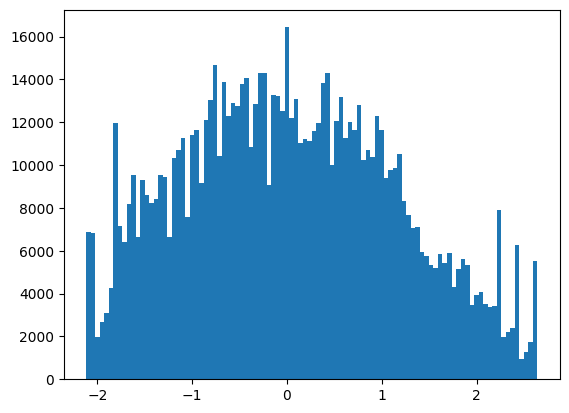

In [46]:
# The pixel histogram after normalisation: centred near zero, spread about 1.
# That is the distribution the pretrained weights expect.
plt.hist(X.data.numpy().flatten(),100);

In [47]:
# Loading ResNet-18 with its ImageNet weights.
# Print it and look at the structure: conv1, then four layer blocks, then avgpool
# and fc. Each block is built from residual units computing f(x) + x - the
# identity shortcut that made very deep networks trainable.
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
print(resnet)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [48]:
# The summary at 96x96 input. ResNet is fully convolutional up to the final
# pooling, so it accepts any input size above a minimum.
torchsummary.summary(resnet.to(device), input_size=(3,96,96), batch_size=bs)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [32, 64, 48, 48]           9,408
       BatchNorm2d-2           [32, 64, 48, 48]             128
              ReLU-3           [32, 64, 48, 48]               0
         MaxPool2d-4           [32, 64, 24, 24]               0
            Conv2d-5           [32, 64, 24, 24]          36,864
       BatchNorm2d-6           [32, 64, 24, 24]             128
              ReLU-7           [32, 64, 24, 24]               0
            Conv2d-8           [32, 64, 24, 24]          36,864
       BatchNorm2d-9           [32, 64, 24, 24]             128
             ReLU-10           [32, 64, 24, 24]               0
       BasicBlock-11           [32, 64, 24, 24]               0
           Conv2d-12           [32, 64, 24, 24]          36,864
      BatchNorm2d-13           [32, 64, 24, 24]             128
             ReLU-14           [32, 64,

In [49]:
# Step 1 of the recipe: replace the 1000-class ImageNet head with a 10-class one.
# 512 is the feature dimension ResNet-18 produces after global pooling.
# A newly created layer has requires_grad=True by default, so it will train.
resnet.fc = nn.Linear(512,10)

In [50]:
# Confirming the new output shape is (batch, 10).
print('Check after changing the fc layer')
torchsummary.summary(resnet.to(device), input_size=(3,96,96), batch_size=bs)

Check after changing the fc layer
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [32, 64, 48, 48]           9,408
       BatchNorm2d-2           [32, 64, 48, 48]             128
              ReLU-3           [32, 64, 48, 48]               0
         MaxPool2d-4           [32, 64, 24, 24]               0
            Conv2d-5           [32, 64, 24, 24]          36,864
       BatchNorm2d-6           [32, 64, 24, 24]             128
              ReLU-7           [32, 64, 24, 24]               0
            Conv2d-8           [32, 64, 24, 24]          36,864
       BatchNorm2d-9           [32, 64, 24, 24]             128
             ReLU-10           [32, 64, 24, 24]               0
       BasicBlock-11           [32, 64, 24, 24]               0
           Conv2d-12           [32, 64, 24, 24]          36,864
      BatchNorm2d-13           [32, 64, 24, 24]             128
     

In [51]:
# Step 2: freeze everything except fc. The backbone becomes a fixed feature
# extractor and only the new classifier learns.
# This is 'feature extraction'. The alternative, fine-tuning, also unfreezes the
# last block or two at a much smaller learning rate - usually worth a few points
# when the target domain is unlike ImageNet.
for name, params in resnet.named_parameters():
    if 'fc' in name:
        params.requires_grad = True
    else:
        params.requires_grad = False

In [52]:
# Verify the freeze. Only fc.weight and fc.bias should print True.
# Checking if the layers are frozen
for name, params in resnet.named_parameters():

  print(f'{name} : {params.requires_grad}')

conv1.weight : False
bn1.weight : False
bn1.bias : False
layer1.0.conv1.weight : False
layer1.0.bn1.weight : False
layer1.0.bn1.bias : False
layer1.0.conv2.weight : False
layer1.0.bn2.weight : False
layer1.0.bn2.bias : False
layer1.1.conv1.weight : False
layer1.1.bn1.weight : False
layer1.1.bn1.bias : False
layer1.1.conv2.weight : False
layer1.1.bn2.weight : False
layer1.1.bn2.bias : False
layer2.0.conv1.weight : False
layer2.0.bn1.weight : False
layer2.0.bn1.bias : False
layer2.0.conv2.weight : False
layer2.0.bn2.weight : False
layer2.0.bn2.bias : False
layer2.0.downsample.0.weight : False
layer2.0.downsample.1.weight : False
layer2.0.downsample.1.bias : False
layer2.1.conv1.weight : False
layer2.1.bn1.weight : False
layer2.1.bn1.bias : False
layer2.1.conv2.weight : False
layer2.1.bn2.weight : False
layer2.1.bn2.bias : False
layer3.0.conv1.weight : False
layer3.0.bn1.weight : False
layer3.0.bn1.bias : False
layer3.0.conv2.weight : False
layer3.0.bn2.weight : False
layer3.0.bn2.bias : 

In [53]:
# Step 3: give the optimizer ONLY the trainable parameters.
# filter(lambda p: p.requires_grad, ...) is the standard idiom. Passing every
# parameter also works - frozen ones have no gradient - but this is explicit and
# avoids allocating optimizer state for tensors that never move.
# lr=1e-3 is fine here because the layer being trained is randomly initialised;
# if the backbone were unfrozen, it would need to be far smaller.
def train_model():

  lossfunc = nn.CrossEntropyLoss()
  epochs = 10
  optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, resnet.parameters()),
    lr=1e-3,
)

  losses = []
  train_acc = []
  val_acc = []



  for epoch in range(epochs):

    resnet.train()

    batch_acc = []
    batch_loss = []

    for x,y in train_loader:
      x = x.to(device)
      y = y.to(device)

      yhat = resnet(x)

      loss = lossfunc(yhat,y)

      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      acc = 100 * torch.mean( (torch.argmax(yhat, dim=1) == y).float().detach().cpu())
      batch_acc.append(acc)

    losses.append(np.mean(batch_loss))
    train_acc.append(np.mean(batch_acc))

    # Now validation

    resnet.eval()
    with torch.no_grad():
      batch_val_acc = []
      for X, Y in test_loader:
        X = X.to(device)
        Y = Y.to(device)
        batch_val_acc.append( 100 * torch.mean( (torch.argmax(resnet(X), dim=1) == Y).float().detach().cpu()) )
      val_acc.append(np.mean(batch_val_acc))


    if epoch % 10 == 0 or epoch == epochs-1 :
      print(f'Epoch {epoch} | Loss : {losses[epoch]:.4f} | Train Acc {train_acc[epoch]} | Val Acc : {val_acc[epoch]}')

  return resnet, losses, train_acc, val_acc

In [54]:
# Train. Ten epochs is enough - only one layer is learning.
resnet, losses, train_acc, val_acc = train_model()

Epoch 0 | Loss : 1.1857 | Train Acc 61.43830108642578 | Val Acc : 75.67138671875
Epoch 9 | Loss : 0.4773 | Train Acc 83.21314239501953 | Val Acc : 79.04052734375


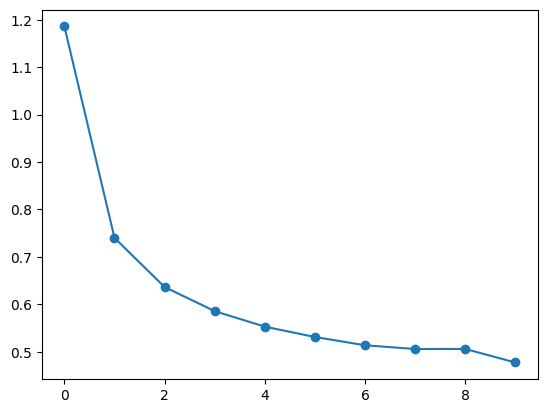

In [69]:
# Loss curve. It starts low and drops fast: the features were already good, only
# the mapping from features to these 10 classes had to be learned.
plt.plot(losses,'o-');

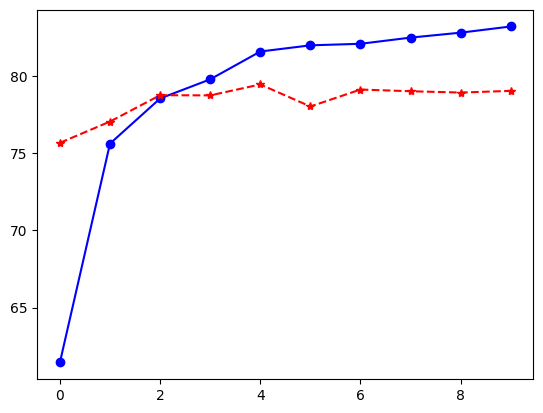

In [71]:
# Train and validation accuracy. Expect high accuracy from 5000 images, which
# would be impossible from scratch. That gap IS transfer learning.
plt.plot(train_acc,'bo-')
plt.plot(val_acc, 'r*--');

In [72]:
# filter() returns a lazy iterator, not a list - fine for the optimizer, which
# consumes it once at construction.
filter(lambda p : p.requires_grad,resnet.parameters())

In [3]:
help(filter)

Help on class filter in module builtins:

class filter(object)
 |  filter(function or None, iterable) --> filter object
 |
 |  Return an iterator yielding those items of iterable for which function(item)
 |  is true. If function is None, return the items that are true.
 |
 |  Methods defined here:
 |
 |  __getattribute__(self, name, /)
 |      Return getattr(self, name).
 |
 |  __iter__(self, /)
 |      Implement iter(self).
 |
 |  __next__(self, /)
 |      Implement next(self).
 |
 |  __reduce__(...)
 |      Return state information for pickling.
 |
 |  ----------------------------------------------------------------------
 |  Static methods defined here:
 |
 |  __new__(*args, **kwargs)
 |      Create and return a new object.  See help(type) for accurate signature.

